EXERCISE A

Top of book = the highest bid and the lowest ask 

Dedupe fully duplicated rows, nothing changed

In [68]:
import polars as pl

df_raw = pl.read_parquet("../parquets/A_hkex_2800_top_of_book.parquet")

df = df_raw.unique().sort("seq_id")

pl.DataFrame({
    "stage": ["raw", "deduped_and_seq_sorted"],
    "rows": [df_raw.height, df.height],
    "columns": [df_raw.width, df.width],
})

stage,rows,columns
str,i64,i64
"""raw""",109544,9
"""deduped_and_seq_sorted""",109544,9


No dupe seq ids
Descending Seq ids spotted
    just order by seq id

In [69]:
df.group_by("seq_id").len().filter(pl.col("len") > 1)

seq_id,len
i64,u32


In [70]:
for col in ["ingress_ts", "transaction_ts", "publish_ts"]:
    dupes = df.group_by(col).len().filter(pl.col("len") > 1)
    print(col, "duplicate timestamp values:", dupes.height, "rows involved:", dupes["len"].sum())

ingress_ts duplicate timestamp values: 23458 rows involved: 77378
transaction_ts duplicate timestamp values: 8890 rows involved: 23764
publish_ts duplicate timestamp values: 8890 rows involved: 23764


Lots of timestamp dupes\
    Ingress, our own system, not necessarily bad. ~75% of rows involved\
    transaction/publish, possible if timestamps are batched. Same number of rows involved too looks intentional. Or from the same venue ?

In [71]:
df = df.sort("seq_id").with_columns(
    same_bbo_as_prev=(
        (pl.col("bid_price") == pl.col("bid_price").shift(1))
        & (pl.col("bid_qty") == pl.col("bid_qty").shift(1))
        & (pl.col("ask_price") == pl.col("ask_price").shift(1))
        & (pl.col("ask_qty") == pl.col("ask_qty").shift(1))
    )
)

df.filter(pl.col("same_bbo_as_prev"))

df.select(
    pl.col("same_bbo_as_prev").sum().alias("same_bbo_as_prev_count")
)

same_bbo_as_prev_count
u32
0


No repeated BBO states\
Overall not enough evidence for duped data



In [72]:
df.sort("seq_id").select(
    pl.col("ingress_ts").is_sorted().alias("ingress_monotonic"),
    pl.col("transaction_ts").is_sorted().alias("transaction_monotonic"),
    pl.col("publish_ts").is_sorted().alias("publish_monotonic"),
)

ingress_monotonic,transaction_monotonic,publish_monotonic
bool,bool,bool
false,false,false


Even after ordering by seq id. timestamps are not monotonic\
    For basic ordering use seq id. For timing analysis, keep timestamp order anomalies flagged

In [73]:
df.filter(
    (pl.col("bid_price") <= 0)
    | (pl.col("ask_price") <= 0)
    | (pl.col("bid_qty") <= 0)
    | (pl.col("ask_qty") <= 0)
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,same_bbo_as_prev
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool


Negative number check, pass\
Timestamp sanity, pass

In [74]:
df.filter(
    (pl.col("ingress_ts") < pl.col("publish_ts"))
    | (pl.col("publish_ts") < pl.col("transaction_ts"))
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,same_bbo_as_prev
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool


In [75]:
df_latency = df.with_columns(
    capture_latency_us = (
        pl.col("ingress_ts") - pl.col("publish_ts")
    ).dt.total_microseconds()
)

df_latency.filter(pl.col("capture_latency_us") > 1_000_000)

df_latency.select(
    pl.col("capture_latency_us").min().alias("min"),
    pl.col("capture_latency_us").quantile(0.5).alias("median"),
    pl.col("capture_latency_us").quantile(0.95).alias("p95"),
    pl.col("capture_latency_us").quantile(0.99).alias("p99"),
    pl.col("capture_latency_us").max().alias("max"),
)

min,median,p95,p99,max
i64,f64,f64,f64,i64
28001,33081.0,40216.0,51337.0,5333363136


In [76]:
latency_us = (pl.col("ingress_ts") - pl.col("publish_ts")).dt.total_microseconds()

p95_latency_us = df.select(latency_us.quantile(0.95)).item()
p99_latency_us = df.select(latency_us.quantile(0.99)).item()

df = df.with_columns(
    capture_latency_us=latency_us,
    latency_gt_p95=latency_us > p95_latency_us,
    latency_gt_p99=latency_us > p99_latency_us,
    latency_gt_1s=latency_us > 1_000_000,
)

In [77]:
df = df.with_columns(
    missing_bid=pl.col("bid_price").is_null() | pl.col("bid_qty").is_null(),
    missing_ask=pl.col("ask_price").is_null() | pl.col("ask_qty").is_null(),
).with_columns(
    quote_state=
        pl.when(pl.col("missing_bid") & pl.col("missing_ask")).then(pl.lit("no_bbo"))
        .when(pl.col("missing_bid")).then(pl.lit("ask_only"))
        .when(pl.col("missing_ask")).then(pl.lit("bid_only"))
        .otherwise(pl.lit("two_sided"))
)

df.group_by("quote_state").len()

quote_state,len
str,u32
"""two_sided""",109541
"""ask_only""",1
"""bid_only""",2


In [78]:
df = df.with_columns(
    spread=pl.col("ask_price") - pl.col("bid_price"),
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
)

df.select(
    pl.col("crossed_book").sum().alias("crossed_book_count"),
    pl.col("locked_book").sum().alias("locked_book_count"),
)

crossed_book_count,locked_book_count
u32,u32
71,112


In [79]:
df = df.with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2
)

df = df.with_columns(
    spread_pct=pl.col("spread") / pl.col("mid") * 100
)

p99_spread_pct = df.select(pl.col("spread_pct").quantile(0.99)).item()

df = df.with_columns(
    spread_outlier=pl.col("spread_pct") > p99_spread_pct
)

df = df.with_columns(spread_outlier=pl.col("spread_pct") > pl.col("spread_pct").quantile(0.99))

df.select(
    pl.col("spread_outlier").sum().alias("spread_outlier_count"),
    pl.col("spread_pct").quantile(0.99).alias("p99_spread_pct"),
    pl.col("spread_pct").max().alias("max_spread_pct"),
)

spread_outlier_count,p99_spread_pct,max_spread_pct
u32,f64,f64
812,0.15444,6.422018


In [80]:
df = df.sort("seq_id").with_columns(
    bid_change_pct=(pl.col("bid_price") / pl.col("bid_price").shift(1) - 1).abs() * 100,
    ask_change_pct=(pl.col("ask_price") / pl.col("ask_price").shift(1) - 1).abs() * 100,
)
df = df.with_columns(
    implausible_price_jump=(pl.col("bid_change_pct") > 10) | (pl.col("ask_change_pct") > 10)
)
df.select(pl.col("implausible_price_jump").sum().alias("implausible_price_jump_count"))

implausible_price_jump_count
u32
0


In [81]:
df.sort("seq_id").with_columns(
    time_gap_s=(pl.col("publish_ts") - pl.col("publish_ts").shift(1)).dt.total_seconds()
).select(
    pl.col("time_gap_s").min().alias("min_gap_s"),
    pl.col("time_gap_s").quantile(0.95).alias("p95_gap_s"),
    pl.col("time_gap_s").quantile(0.99).alias("p99_gap_s"),
    pl.col("time_gap_s").max().alias("max_gap_s"),
)

min_gap_s,p95_gap_s,p99_gap_s,max_gap_s
i64,f64,f64,i64
-5333,0.0,3.0,5333


In [82]:
df = df.sort("seq_id").with_columns(
    time_gap_s=(pl.col("publish_ts") - pl.col("publish_ts").shift(1)).dt.total_seconds()
).with_columns(
    large_time_gap=pl.col("time_gap_s").abs() > 60
)

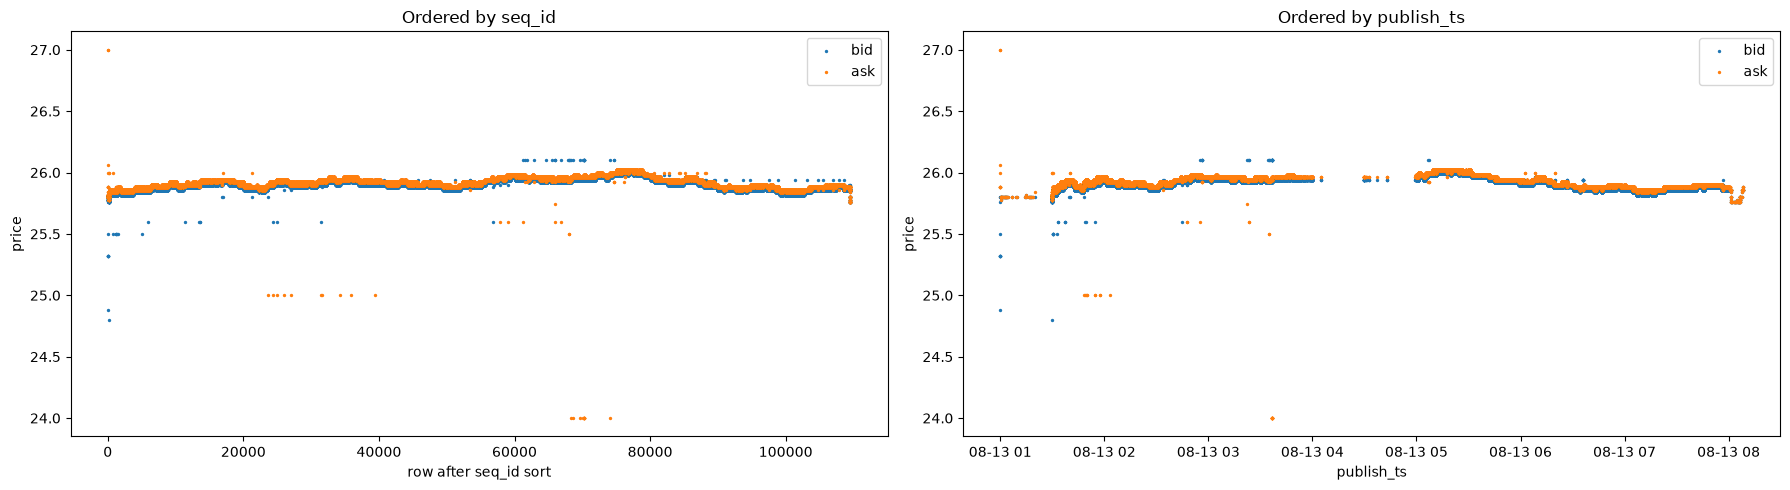

In [83]:
import matplotlib.pyplot as plt

df_seq = df.sort("seq_id").with_row_index("row")
df_time = df.sort(["publish_ts", "seq_id"])

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].scatter(df_seq["row"], df_seq["bid_price"], s=2, label="bid")
ax[0].scatter(df_seq["row"], df_seq["ask_price"], s=2, label="ask")
ax[0].set_title("Ordered by seq_id")
ax[0].set_xlabel("row after seq_id sort")
ax[0].set_ylabel("price")
ax[0].legend()

ax[1].scatter(df_time["publish_ts"], df_time["bid_price"], s=2, label="bid")
ax[1].scatter(df_time["publish_ts"], df_time["ask_price"], s=2, label="ask")
ax[1].set_title("Ordered by publish_ts")
ax[1].set_xlabel("publish_ts")
ax[1].set_ylabel("price")
ax[1].legend()

plt.tight_layout()
plt.show()

In [84]:
df = df.drop("session_phase", strict=False).with_columns(
    minute_of_day=pl.col("publish_ts").dt.hour() * 60 + pl.col("publish_ts").dt.minute()
).with_columns(
    session_phase=
        pl.when(pl.col("minute_of_day") < 60).then(pl.lit("before_open"))
        .when(pl.col("minute_of_day") < 90).then(pl.lit("pre_open"))
        .when(pl.col("minute_of_day") < 240).then(pl.lit("morning_continuous"))
        .when(pl.col("minute_of_day") < 300).then(pl.lit("lunch_break"))
        .when(pl.col("minute_of_day") < 480).then(pl.lit("afternoon_continuous"))
        .when(pl.col("minute_of_day") <= 490).then(pl.lit("closing_auction"))
        .otherwise(pl.lit("after_close"))
)

In [85]:
df.group_by("session_phase").agg(
    pl.col("publish_ts").min().alias("min_publish_ts"),
    pl.col("publish_ts").max().alias("max_publish_ts"),
    pl.len().alias("rows"),
).sort("min_publish_ts")

session_phase,min_publish_ts,max_publish_ts,rows
str,"datetime[μs, UTC]","datetime[μs, UTC]",u32
"""pre_open""",2026-08-13 01:00:00.082890 UTC,2026-08-13 05:45:58.216380 UTC,5116
"""morning_continuous""",2026-08-13 01:30:00.002550 UTC,2026-08-13 06:23:59.594660 UTC,49392
"""before_open""",2026-08-13 02:08:00.024120 UTC,2026-08-13 08:08:12.709010 UTC,55036


In [86]:
minute_of_day = (
    pl.col("publish_ts").dt.hour().cast(pl.Int32) * 60
    + pl.col("publish_ts").dt.minute().cast(pl.Int32)
)

df = df.drop(["session_phase", "minute_of_day"], strict=False).with_columns(
    minute_of_day=minute_of_day
).with_columns(
    session_phase=
        pl.when(pl.col("minute_of_day") < 60).then(pl.lit("before_open"))
        .when(pl.col("minute_of_day") < 90).then(pl.lit("pre_open"))
        .when(pl.col("minute_of_day") < 240).then(pl.lit("morning_continuous"))
        .when(pl.col("minute_of_day") < 300).then(pl.lit("lunch_break"))
        .when(pl.col("minute_of_day") < 480).then(pl.lit("afternoon_continuous"))
        .when(pl.col("minute_of_day") <= 490).then(pl.lit("closing_auction"))
        .otherwise(pl.lit("after_close"))
)

In [87]:
df.group_by("session_phase").agg(
    pl.col("minute_of_day").min().alias("min_minute"),
    pl.col("minute_of_day").max().alias("max_minute"),
    pl.col("publish_ts").min().alias("min_publish_ts"),
    pl.col("publish_ts").max().alias("max_publish_ts"),
    pl.len().alias("rows"),
).sort("min_minute")

session_phase,min_minute,max_minute,min_publish_ts,max_publish_ts,rows
str,i32,i32,"datetime[μs, UTC]","datetime[μs, UTC]",u32
"""pre_open""",60,80,2026-08-13 01:00:00.082890 UTC,2026-08-13 01:20:03.782040 UTC,50
"""morning_continuous""",90,239,2026-08-13 01:30:00.002550 UTC,2026-08-13 03:59:59.494730 UTC,70157
"""lunch_break""",245,299,2026-08-13 04:05:00.007010 UTC,2026-08-13 04:59:01.204940 UTC,36
"""afternoon_continuous""",300,479,2026-08-13 05:00:00.002430 UTC,2026-08-13 07:59:59.991970 UTC,39219
"""closing_auction""",481,488,2026-08-13 08:01:00.013880 UTC,2026-08-13 08:08:12.709010 UTC,82


In [91]:
df.filter(
    pl.col("session_phase").is_in(["morning_continuous", "afternoon_continuous"])
).select(
    pl.col("capture_latency_us").min().alias("min_us"),
    pl.col("capture_latency_us").quantile(0.50).alias("p50_us"),
    pl.col("capture_latency_us").quantile(0.95).alias("p95_us"),
    pl.col("capture_latency_us").quantile(0.99).alias("p99_us"),
    pl.col("capture_latency_us").max().alias("max_us"),
)

min_us,p50_us,p95_us,p99_us,max_us
i64,f64,f64,f64,i64
28001,33079.0,40171.0,50585.0,5333363136


In [92]:
df.select(
    pl.len().alias("rows"),
    pl.col("same_bbo_as_prev").sum().alias("same_bbo_as_prev"),
    pl.col("latency_gt_p95").sum().alias("latency_gt_p95"),
    pl.col("latency_gt_p99").sum().alias("latency_gt_p99"),
    pl.col("latency_gt_1s").sum().alias("latency_gt_1s"),
    (pl.col("quote_state") != "two_sided").sum().alias("incomplete_bbo"),
    pl.col("crossed_book").sum().alias("crossed_book"),
    pl.col("locked_book").sum().alias("locked_book"),
    pl.col("spread_outlier").sum().alias("spread_outlier"),
    pl.col("large_time_gap").sum().alias("large_time_gap"),
)

rows,same_bbo_as_prev,latency_gt_p95,latency_gt_p99,latency_gt_1s,incomplete_bbo,crossed_book,locked_book,spread_outlier,large_time_gap
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
109544,0,5475,1095,59,3,71,112,812,107


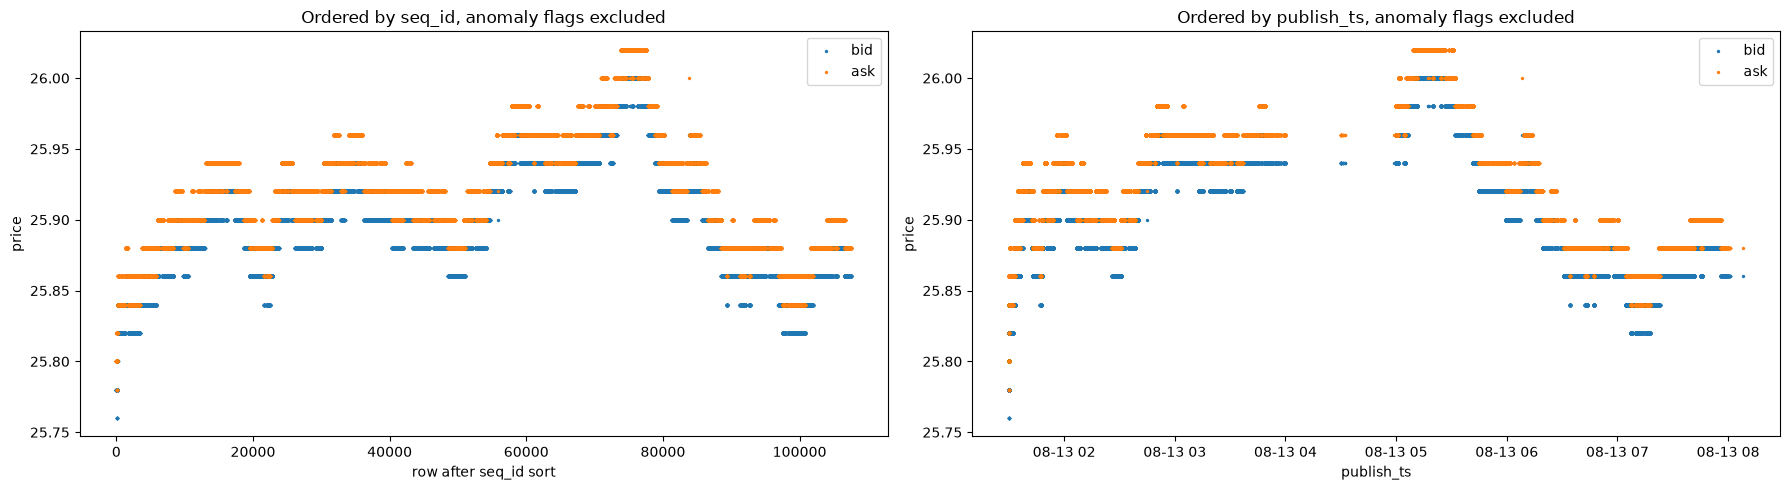

In [93]:
df_plot = df.filter(
    (pl.col("quote_state") == "two_sided")
    & (~pl.col("crossed_book"))
    & (~pl.col("locked_book"))
    & (~pl.col("spread_outlier"))
    & (~pl.col("latency_gt_p99"))
    & (~pl.col("latency_gt_1s"))
    & (~pl.col("large_time_gap"))
)

df_seq = df_plot.sort("seq_id").with_row_index("row")
df_time = df_plot.sort(["publish_ts", "seq_id"])

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].scatter(df_seq["row"], df_seq["bid_price"], s=2, label="bid")
ax[0].scatter(df_seq["row"], df_seq["ask_price"], s=2, label="ask")
ax[0].set_title("Ordered by seq_id, anomaly flags excluded")
ax[0].set_xlabel("row after seq_id sort")
ax[0].set_ylabel("price")
ax[0].legend()

ax[1].scatter(df_time["publish_ts"], df_time["bid_price"], s=2, label="bid")
ax[1].scatter(df_time["publish_ts"], df_time["ask_price"], s=2, label="ask")
ax[1].set_title("Ordered by publish_ts, anomaly flags excluded")
ax[1].set_xlabel("publish_ts")
ax[1].set_ylabel("price")
ax[1].legend()

plt.tight_layout()
plt.show()

very tight range. looks better

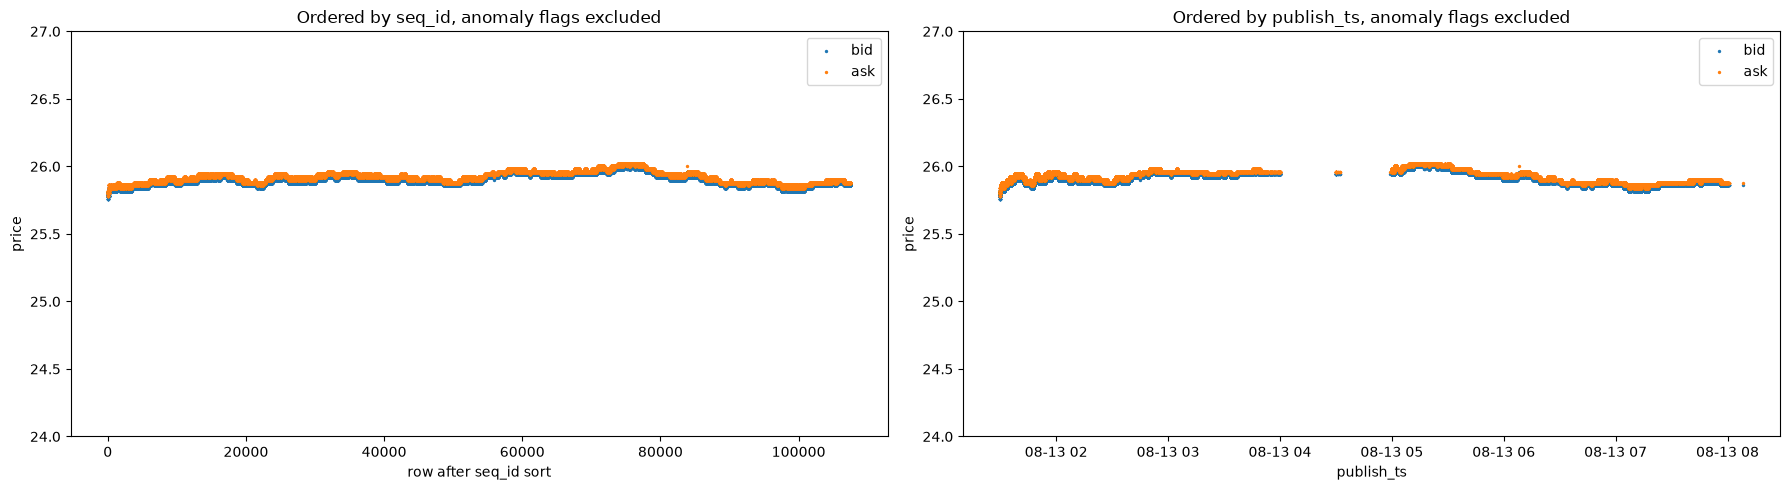

In [94]:
df_plot = df.filter(
    (pl.col("quote_state") == "two_sided")
    & (~pl.col("crossed_book"))
    & (~pl.col("locked_book"))
    & (~pl.col("spread_outlier"))
    & (~pl.col("latency_gt_p99"))
    & (~pl.col("latency_gt_1s"))
    & (~pl.col("large_time_gap"))
)

df_seq = df_plot.sort("seq_id").with_row_index("row")
df_time = df_plot.sort(["publish_ts", "seq_id"])

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].scatter(df_seq["row"], df_seq["bid_price"], s=2, label="bid")
ax[0].scatter(df_seq["row"], df_seq["ask_price"], s=2, label="ask")
ax[0].set_title("Ordered by seq_id, anomaly flags excluded")
ax[0].set_xlabel("row after seq_id sort")
ax[0].set_ylabel("price")
ax[0].set_ylim(24, 27)
ax[0].legend()

ax[1].scatter(df_time["publish_ts"], df_time["bid_price"], s=2, label="bid")
ax[1].scatter(df_time["publish_ts"], df_time["ask_price"], s=2, label="ask")
ax[1].set_title("Ordered by publish_ts, anomaly flags excluded")
ax[1].set_xlabel("publish_ts")
ax[1].set_ylabel("price")
ax[1].set_ylim(24, 27)
ax[1].legend()

plt.tight_layout()
plt.show()

In [97]:
df_plot.sort(["publish_ts", "seq_id"]).with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2
).with_columns(
    mid_change_pct=(pl.col("mid") / pl.col("mid").shift(1) - 1).abs() * 100
).sort("mid_change_pct", descending=True, nulls_last=True).head(10)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,same_bbo_as_prev,capture_latency_us,latency_gt_p95,latency_gt_p99,latency_gt_1s,missing_bid,missing_ask,quote_state,spread,crossed_book,locked_book,mid,spread_pct,spread_outlier,bid_change_pct,ask_change_pct,implausible_price_jump,time_gap_s,large_time_gap,minute_of_day,session_phase,mid_change_pct
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,i64,bool,bool,bool,bool,bool,str,f64,bool,bool,f64,f64,bool,f64,f64,bool,i64,bool,i32,str,f64
"""S|2800-HKD:SPOT""",2026-08-13 06:08:22.668961 UTC,2026-08-13 06:08:22.628300 UTC,2026-08-13 06:08:22.628300 UTC,109025452,25.96,80.0,26.0,275.0,false,40661,true,false,false,false,false,"""two_sided""",0.04,false,false,25.98,0.153965,false,0.154321,0.231303,false,0,false,368,"""afternoon_continuous""",0.192827
"""S|2800-HKD:SPOT""",2026-08-13 06:08:22.824823 UTC,2026-08-13 06:08:22.791440 UTC,2026-08-13 06:08:22.791440 UTC,109025754,25.92,2.05585e7,25.94,1.2125e7,false,33383,false,false,false,false,false,"""two_sided""",0.02,false,false,25.93,0.077131,false,0.154083,0.230769,false,0,false,368,"""afternoon_continuous""",0.192456
"""S|2800-HKD:SPOT""",2026-08-13 01:30:02.273398 UTC,2026-08-13 01:30:02.242940 UTC,2026-08-13 01:30:02.242940 UTC,60094652,25.78,184500.0,25.8,915500.0,false,30458,false,false,false,false,false,"""two_sided""",0.02,false,false,25.79,0.077549,false,0.07764,0.0,false,0,false,90,"""morning_continuous""",0.07761
"""S|2800-HKD:SPOT""",2026-08-13 01:30:00.291277 UTC,2026-08-13 01:30:00.253470 UTC,2026-08-13 01:30:00.253470 UTC,60067851,25.8,126000.0,25.82,624000.0,false,37807,false,false,false,false,false,"""two_sided""",0.02,false,false,25.81,0.077489,false,0.07758,0.0,false,0,false,90,"""morning_continuous""",0.077549
"""S|2800-HKD:SPOT""",2026-08-13 01:30:06.763549 UTC,2026-08-13 01:30:06.732390 UTC,2026-08-13 01:30:06.732390 UTC,60139525,25.8,164000.0,25.82,1.3415e6,false,31159,false,false,false,false,false,"""two_sided""",0.02,false,false,25.81,0.077489,false,0.07758,0.0,false,0,false,90,"""morning_continuous""",0.077549
"""S|2800-HKD:SPOT""",2026-08-13 01:30:01.816806 UTC,2026-08-13 01:30:01.783720 UTC,2026-08-13 01:30:01.783720 UTC,60086364,25.76,989000.0,25.78,156000.0,false,33086,false,false,false,false,false,"""two_sided""",0.02,false,false,25.77,0.07761,false,0.0,0.077519,false,0,false,90,"""morning_continuous""",0.077549
"""S|2800-HKD:SPOT""",2026-08-13 01:30:00.041569 UTC,2026-08-13 01:30:00.007430 UTC,2026-08-13 01:30:00.007430 UTC,60059740,25.78,11000.0,25.8,500000.0,false,34139,false,false,false,false,false,"""two_sided""",0.02,false,false,25.79,0.077549,false,0.0,0.077459,false,0,false,90,"""morning_continuous""",0.077489
"""S|2800-HKD:SPOT""",2026-08-13 01:30:01.284127 UTC,2026-08-13 01:30:01.254680 UTC,2026-08-13 01:30:01.254680 UTC,60081389,25.78,662000.0,25.8,53000.0,false,29447,false,false,false,false,false,"""two_sided""",0.02,false,false,25.79,0.077549,false,0.0,0.077459,false,0,false,90,"""morning_continuous""",0.077489
"""S|2800-HKD:SPOT""",2026-08-13 01:30:07.789131 UTC,2026-08-13 01:30:07.756180 UTC,2026-08-13 01:30:07.756180 UTC,60149820,25.82,159000.0,25.84,1.0195e6,false,32951,false,false,false,false,false,"""two_sided""",0.02,false,false,25.83,0.077429,false,0.077519,0.0,false,0,false,90,"""morning_continuous""",0.077489
